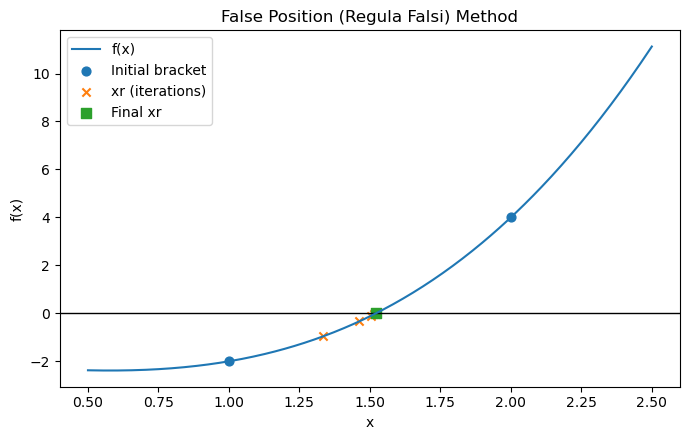

    iter        xl   xu        xr         f(xl)  f(xu)         f(xr)  \
0      1  1.000000  2.0  1.333333 -2.000000e+00    4.0 -9.629630e-01   
1      2  1.333333  2.0  1.462687 -9.629630e-01    4.0 -3.333389e-01   
2      3  1.462687  2.0  1.504019 -3.333389e-01    4.0 -1.018180e-01   
3      4  1.504019  2.0  1.516331 -1.018180e-01    4.0 -2.989480e-02   
4      5  1.516331  2.0  1.519919 -2.989480e-02    4.0 -8.675066e-03   
5      6  1.519919  2.0  1.520957 -8.675066e-03    4.0 -2.508805e-03   
6      7  1.520957  2.0  1.521258 -2.508805e-03    4.0 -7.248228e-04   
7      8  1.521258  2.0  1.521344 -7.248228e-04    4.0 -2.093499e-04   
8      9  1.521344  2.0  1.521370 -2.093499e-04    4.0 -6.046133e-05   
9     10  1.521370  2.0  1.521377 -6.046133e-05    4.0 -1.746113e-05   
10    11  1.521377  2.0  1.521379 -1.746113e-05    4.0 -5.042711e-06   
11    12  1.521379  2.0  1.521379 -5.042711e-06    4.0 -1.456314e-06   
12    13  1.521379  2.0  1.521380 -1.456314e-06    4.0 -4.205770

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Define the function ----
def f(x):
    # Example function: x^3 - x - 2 = 0 has a root near 1.521
    return x**3 - x - 2

# ---- False Position Method ----
def false_position(f, xl, xu, tol=1e-6, max_iter=100):
    if f(xl) * f(xu) > 0:
        raise ValueError("f(xl) and f(xu) must have opposite signs to bracket a root.")
        
    records = []
    xr_old = None
    
    for i in range(1, max_iter + 1):
        fl, fu = f(xl), f(xu)
        # Regula Falsi update
        xr = xu - fu * (xl - xu) / (fl - fu)
        fr = f(xr)
        
        # Approximate relative error
        if xr_old is None:
            ea = np.nan
        else:
            ea = abs((xr - xr_old) / xr)
        
        records.append({
            "iter": i,
            "xl": xl,
            "xu": xu,
            "xr": xr,
            "f(xl)": fl,
            "f(xu)": fu,
            "f(xr)": fr,
            "rel_error": ea
        })
        
        # Update bracket
        if fl * fr < 0:
            xu = xr
        elif fr * fu < 0:
            xl = xr
        else:
            # Found exact root
            break
        
        # Stop if tolerance reached
        if xr_old is not None and abs(xr - xr_old) < tol:
            break
        xr_old = xr
    
    df = pd.DataFrame(records)
    return df

# ---- Parameters ----
xl, xu = 1.0, 2.0   # interval
tol = 1e-8
max_iter = 100

# Run method
df_iters = false_position(f, xl, xu, tol, max_iter)

# ---- Visualization ----
x_plot = np.linspace(xl - 0.5, xu + 0.5, 400)
y_plot = f(x_plot)

plt.figure(figsize=(7, 4.5))
plt.axhline(0, linewidth=1, color='black')

plt.plot(x_plot, y_plot, linewidth=1.5, label="f(x)")

# Initial bracket points
plt.scatter([xl, xu], [f(xl), f(xu)], marker='o', s=40, label="Initial bracket")

# Iteration xr points
plt.scatter(df_iters["xr"].values, df_iters["f(xr)"].values, marker='x', s=35, label="xr (iterations)")

# Final estimate
xr_best = df_iters["xr"].iloc[-1]
plt.scatter([xr_best], [f(xr_best)], marker='s', s=50, label="Final xr")

plt.title("False Position (Regula Falsi) Method")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Show iteration table ----
print(df_iters)
